In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import string

df = pd.read_csv('../data/raw/phishing_urls.csv')

In [29]:
print(df.shape)
print(df.dtypes)
df.head(10)

(235795, 56)
FILENAME                       object
URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64

,FILENAME,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,521848.txt,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,...,0,0,1,34,20,28,119,0,124,1
1,31372.txt,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,...,0,0,1,50,9,8,39,0,217,1
2,597387.txt,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,...,0,0,1,10,2,7,42,2,5,1
3,554095.txt,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,...,1,1,1,3,27,15,22,1,31,1
4,151578.txt,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,...,1,0,1,244,15,34,72,1,85,1
5,23107.txt,https://www.globalreporting.org,30,www.globalreporting.org,23,0,org,100.0,1.000000,0.079963,...,0,0,1,35,1,11,86,0,14,1
6,23034.txt,https://www.saffronart.com,25,www.saffronart.com,18,0,com,100.0,1.000000,0.522907,...,0,0,1,32,4,14,44,2,17,1
7,696732.txt,https://www.nerdscandy.com,25,www.nerdscandy.com,18,0,com,100.0,1.000000,0.522907,...,0,0,1,24,2,22,36,0,15,1
8,739255.txt,https://www.hyderabadonline.in,29,www.hyderabadonline.in,22,0,in,100.0,1.000000,0.005084,...,0,0,1,71,4,9,40,1,317,1
9,14486.txt,https://www.aap.org,18,www.aap.org,11,0,org,100.0,1.000000,0.079963,...,0,0,1,10,1,12,173,6,65,1


In [30]:
print(df.isnull().sum())
print("---")
print("Duplicate URLs:", df.duplicated().sum())

FILENAME                      0
URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitle

In [31]:
print(df.columns.tolist())

['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label']


In [32]:
total = len(df)

legit_count    = df[df['label'] == 1].shape[0]
phishing_count = df[df['label'] == 0].shape[0]

legit_pct    = (legit_count / total) * 100
phishing_pct = (phishing_count / total) * 100

print(f"Total URLs      : {total:,}")
print(f"Legitimate (1)  : {legit_count:,}  ({legit_pct:.1f}%)")
print(f"Phishing   (0)  : {phishing_count:,}  ({phishing_pct:.1f}%)")

Total URLs      : 235,795
Legitimate (1)  : 134,850  (57.2%)
Phishing   (0)  : 100,945  (42.8%)


In [33]:
phishing = df[df['label'] == 0]['URL']
legit    = df[df['label'] == 1]['URL']

print("PHISHING:")
print(phishing.sample(5).values)

print("\nLEGIT:")
print(legit.sample(5).values)

PHISHING:
['http://www.koryogroup.1apps.com'
 'http://ggemminiilogin.godaddysites.com/' 'https://dhl-net.web.app/'
 'https://mail-105902.weeblysite.com/'
 'https://aol-mail-102038.weeblysite.com/']

LEGIT:
['https://www.theblackseedco.com.au' 'https://www.giveneuhq.com'
 'https://www.magentostoredevelopment.com' 'https://www.paulcarrjazz.com'
 'https://www.reiok.org']


In [34]:
# label: 0 = phishing, 1 = legitimate
print(df.groupby('label')['URLLength'].mean())

label
0    45.720293
1    26.228610
Name: URLLength, dtype: float64


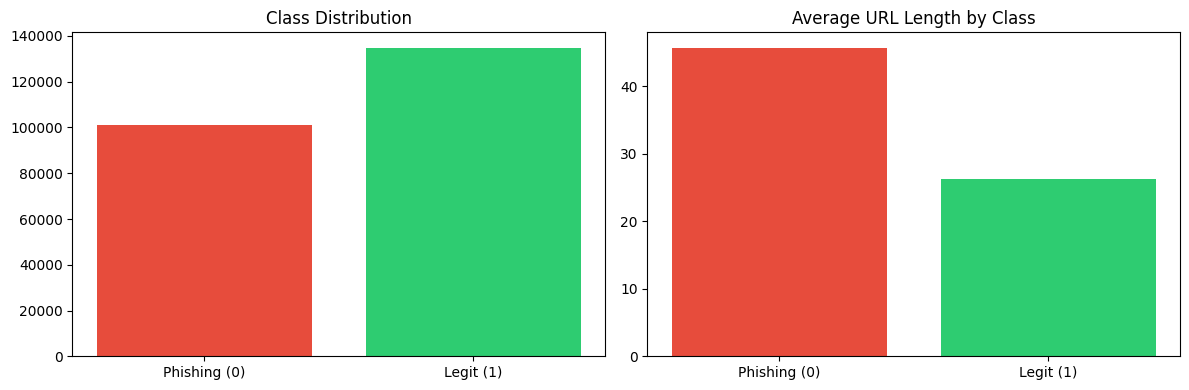

In [35]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# map label numbers to names so it labels itself
label_names = {0: 'Phishing (0)', 1: 'Legit (1)'}
colors      = {0: '#e74c3c',      1: '#2ecc71'}

# Class distribution
counts = df['label'].value_counts().sort_index()
axes[0].bar(
    [label_names[i] for i in counts.index],
    counts.values,
    color=[colors[i] for i in counts.index]
)
axes[0].set_title('Class Distribution')

# URL length by class
url_means = df.groupby('label')['URLLength'].mean().sort_index()
axes[1].bar(
    [label_names[i] for i in url_means.index],
    url_means.values,
    color=[colors[i] for i in url_means.index]
)
axes[1].set_title('Average URL Length by Class')

plt.tight_layout()
plt.show()

In [36]:
# Feature Engineering: Extracting features from URLs
# 0 = Phishing, 1 = Legitimate
drop_cols = ['FILENAME', 'URL', 'Title', 'Domain']

X = df.drop(columns=drop_cols + ['label'])
y = df['label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (235795, 51)
Target shape: (235795,)


In [37]:
print("Total nulls in X:", X.isnull().sum().sum())

Total nulls in X: 0


In [38]:
print(X.dtypes.value_counts())
print(X.select_dtypes(include='object').columns.tolist())

int64      40
float64    10
object      1
Name: count, dtype: int64
['TLD']


In [39]:
X = X.drop(columns=['TLD'])
print("New shape:", X.shape)
print("Remaining object columns:", X.select_dtypes(include='object').columns.tolist())

New shape: (235795, 50)
Remaining object columns: []


In [40]:
#Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set: ", X_test.shape)

# confirm the ratio is preserved
print("\nTrain label ratio:")
print(y_train.value_counts(normalize=True))
print("\nTest label ratio:")
print(y_test.value_counts(normalize=True))

Training set: (188636, 50)
Testing set:  (47159, 50)

Train label ratio:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

Test label ratio:
label
1    0.571895
0    0.428105
Name: proportion, dtype: float64


In [41]:
#Train the first model: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,  # 100 decision trees voting together
    random_state=42,   # reproducible results
    n_jobs=-1          # use all your CPU cores
)

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legit']))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      1.00      1.00     20189
       Legit       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



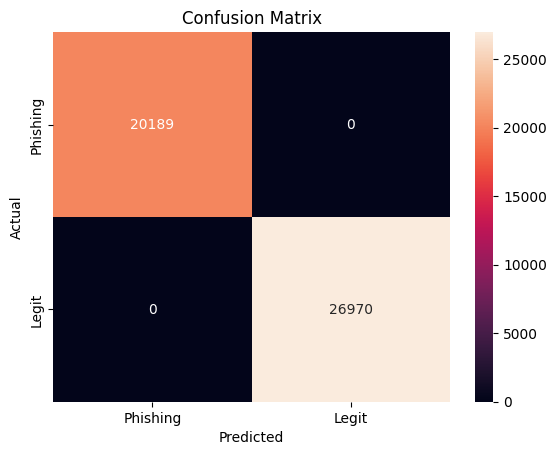

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', 
            xticklabels=['Phishing', 'Legit'],
            yticklabels=['Phishing', 'Legit'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [44]:
# Check if any column is too correlated with the label
correlations = df[X.columns].corrwith(df['label']).abs().sort_values(ascending=False)
print(correlations.head(10))

print(X.columns.tolist())

URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
dtype: float64
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExte

In [45]:
url_only_features = [
    'URLLength', 'DomainLength', 'IsDomainIP',
    'TLDLength', 'NoOfSubDomain', 'IsHTTPS',
    'NoOfLettersInURL', 'LetterRatioInURL',
    'NoOfDegitsInURL', 'DegitRatioInURL',
    'NoOfEqualsInURL', 'NoOfQMarkInURL',
    'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
    'SpacialCharRatioInURL', 'CharContinuationRate',
    'URLCharProb', 'HasObfuscation', 'NoOfObfuscatedChar',
    'ObfuscationRatio', 'TLDLegitimateProb'
]

X_url = df[url_only_features]
y = df['label']

print("URL-only features shape:", X_url.shape)
print("Number of features:", len(url_only_features))

URL-only features shape: (235795, 21)
Number of features: 21


In [46]:
X_url_train, X_url_test, y_url_train, y_url_test = train_test_split(
    X_url, y, test_size=0.2, random_state=42, stratify=y
)

print("URL Train shape:", X_url_train.shape)
print("URL Test shape:", X_url_test.shape)

URL Train shape: (188636, 21)
URL Test shape: (47159, 21)


In [47]:
model_url = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_url.fit(X_url_train, y_url_train)
print("URL-only model trained!")

URL-only model trained!


In [48]:
y_url_pred = model_url.predict(X_url_test)

print("Accuracy:", accuracy_score(y_url_test, y_url_pred))
print("\nClassification Report:")
print(classification_report(y_url_test, y_url_pred, 
      target_names=['Phishing', 'Legit']))

Accuracy: 0.9964799932144448

Classification Report:
              precision    recall  f1-score   support

    Phishing       1.00      0.99      1.00     20189
       Legit       1.00      1.00      1.00     26970

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



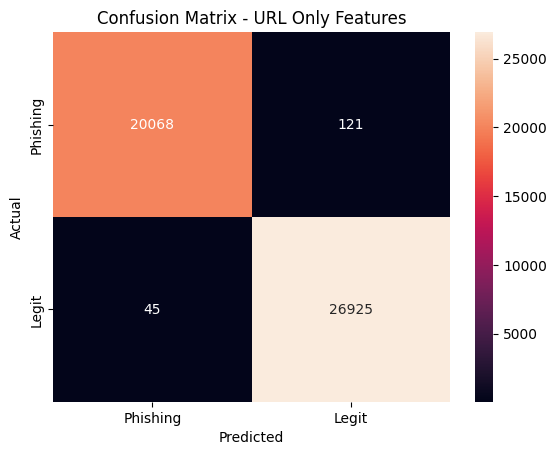

Correctly caught phishing:     26,925
Missed phishing (dangerous!):  45
Wrongly flagged legit:         121
Correctly identified legit:    20,068


In [49]:
cm = confusion_matrix(y_url_test, y_url_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Phishing', 'Legit'],
            yticklabels=['Phishing', 'Legit'])
plt.title('Confusion Matrix - URL Only Features')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Show exact mistakes
tn, fp, fn, tp = cm.ravel()
print(f"Correctly caught phishing:     {tp:,}")
print(f"Missed phishing (dangerous!):  {fn:,}")
print(f"Wrongly flagged legit:         {fp:,}")
print(f"Correctly identified legit:    {tn:,}")

In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_url_test, y_url_pred,
      target_names=['Phishing', 'Legit'],
      digits=4))

              precision    recall  f1-score   support

    Phishing     0.9978    0.9940    0.9959     20189
       Legit     0.9955    0.9983    0.9969     26970

    accuracy                         0.9965     47159
   macro avg     0.9966    0.9962    0.9964     47159
weighted avg     0.9965    0.9965    0.9965     47159

